# 07 — Experimento 4: FinBERT (feature extraction 4a + fine-tuning 4b)

Cuarto experimento: `ProsusAI/finbert`, un BERT preentrenado sobre texto financiero. A diferencia
de Word2Vec (un vector fijo por palabra, promediado), FinBERT produce embeddings **contextuales**:
lee la secuencia entera y "raise rates" ≠ "raise concerns".

- **4a — feature extraction:** FinBERT congelado, se extrae el embedding [CLS] (768 dim) y se
  entrena una regresión logística encima.
- **4b — fine-tuning:** se agrega una capa de clasificación y se ajustan TODOS los pesos.

**Texto:** a diferencia de Exp 1–3 (que usan el texto preprocesado), FinBERT usa el **texto crudo**
de las minutas (`data/raw/minutes/`), porque depende del lenguaje natural (puntuación, stopwords,
orden). El preprocesamiento agresivo lo perjudicaría.

**Truncado** (las minutas superan los 512 tokens de BERT): se evalúan dos estrategias en val.

**Dependencias:** `pip install torch transformers "accelerate>=1.1.0"` (el `Trainer` de
HuggingFace requiere `accelerate`). En Python 3.14 torch/transformers/gensim pueden no instalar;
usar Python ≤ 3.12 (o la PC con GPU).

**Cómputo:** 4a corre en CPU/MPS (lento pero viable); **4b conviene en GPU** (la del usuario).
Device se detecta automáticamente.

**Input:** `data/processed/fomc_dataset.csv` (labels/splits) + `data/raw/minutes/` (texto crudo).
**Outputs:** figuras en `reports/figures/` (`07a_confusion_*.png`, `07b_confusion_*.png`).

In [1]:
import re
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from transformers import (AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

sns.set_theme(style='whitegrid', palette='Set2')

BASE_DIR       = Path('..').resolve()
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
MINUTES_DIR    = BASE_DIR / 'data' / 'raw' / 'minutes'
REPORTS_DIR    = BASE_DIR / 'reports' / 'figures'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

LABEL_ORDER = ['hike', 'cut', 'hold']
MODEL_NAME  = 'ProsusAI/finbert'

device = torch.device('cuda' if torch.cuda.is_available() else
                      ('mps' if torch.backends.mps.is_available() else 'cpu'))
print('Device:', device)

def save_fig(name):
    plt.savefig(REPORTS_DIR / name, dpi=120, bbox_inches='tight')

D:\User\Documentos\ITBA_YO\3er\2do_cuatrimestre\NLP\TP_NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 0. Datos: labels/splits del dataset + texto CRUDO de las minutas

Cargamos `fomc_dataset.csv` por sus columnas `date`/`label`/`split`, pero reemplazamos el texto
por el **crudo** de `data/raw/minutes/{fecha}_minutes.txt` (solo normalizamos espacios).

In [2]:
df = pd.read_csv(DATA_PROCESSED / 'fomc_dataset.csv', parse_dates=['date'])

# --- Enmascarado de la decisión (anti-leakage) ---
# Las minutas mencionan EXPLÍCITAMENTE la decisión tomada ("the Committee decided to raise/lower/
# maintain... to X percent", y el directive viejo "consistent with ... federal funds rate at X
# percent"). Si no se quita, FinBERT podría LEER la decisión en vez de inferirla. Removemos esas
# frases + los valores de tasa de la decisión (~0.7% del texto). Mismo criterio que el dataset
# enmascarado de los exp 1-3. No es 100% leakage-free por el texto garbleado del PDF (ver
# Limitaciones), pero saca el tell explícito en el 100% de los docs.
_V = (r'(raise|raising|increase|increasing|lower|lowering|reduce|reducing|reduced|maintain|'
      r'maintaining|keep|keeping|leave|leaving|unchanged|hold|holding)')
def mask_decision(t):
    pats = [
        r'(?:decided|agreed|voted|chose)\b.{0,80}?to ' + _V + r'\b.{0,200}?(?:percent\.?|\.)',
        r'members\b.{0,60}?to ' + _V + r'\b.{0,200}?(?:percent\.?|\.)',
        r'target (?:range )?for the federal funds rate\b.{0,90}?percent',
        r'(?:in a |to a )?target range of\b.{0,60}?percent',
        r'(?:consistent with|toward|maintaining|keeping)\b.{0,60}?federal funds rate\b.{0,70}?percent',
        _V + r'\b.{0,30}?(?:the )?federal funds rate\b.{0,70}?percent',
        r'(?:funds rate|target[^.]{0,40})\b[^.]{0,40}?\d[\d\s./⁄¼½¾⅛⅜⅝⅞-]{0,10}(?:to\s+)?[\d\s./⁄¼½¾⅛⅜⅝⅞-]{0,10}percent',
    ]
    for p in pats:
        t = re.sub(p, ' ', t, flags=re.I | re.S)
    t = re.sub(r'\d[\d\s./⁄¼½¾⅛⅜⅝⅞-]{0,8}to\s+\d[\d\s./⁄¼½¾⅛⅜⅝⅞-]{0,8}percent', ' ', t, flags=re.I)
    t = re.sub(r'(?:decided|agreed|voted|chose)\b.{0,80}?to ' + _V + r'\w*', ' ', t, flags=re.I | re.S)
    t = re.sub(r'members\b.{0,60}?to ' + _V + r'\w*', ' ', t, flags=re.I | re.S)
    return t

def raw_text(date):
    f = MINUTES_DIR / f"{pd.to_datetime(date).strftime('%Y-%m-%d')}_minutes.txt"
    txt = f.read_text(encoding='utf-8', errors='replace')
    txt = re.sub(r'\s+', ' ', txt).strip()  # colapsar espacios
    return mask_decision(txt)               # quitar la decisión explícita

df['raw'] = df['date'].apply(raw_text)

train = df[df.split == 'train']
val   = df[df.split == 'val']
test  = df[df.split == 'test']
print('train:', len(train), '| val:', len(val), '| test:', len(test))
print('Largo medio (caracteres) crudo enmascarado:', int(df['raw'].str.len().mean()))

train: 145 | val: 32 | test: 32
Largo medio (caracteres) crudo enmascarado: 47998


In [3]:
# Helper de evaluación (mismo criterio que notebooks 04-06)
def evaluar(y_true, y_pred, titulo, fname=None):
    clases = [c for c in LABEL_ORDER if c in set(y_true)]
    f1 = f1_score(y_true, y_pred, labels=clases, average='macro')
    print(titulo)
    print('accuracy :', round(accuracy_score(y_true, y_pred), 4))
    print(f'f1_macro : {round(f1, 4)}  (sobre {len(clases)} clases: {clases})')
    print(classification_report(y_true, y_pred, labels=LABEL_ORDER, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, ax=ax)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); ax.set_title(titulo)
    if fname: save_fig(fname)
    plt.show()
    return f1

## 1. Tokenizer y estrategias de truncado

BERT acepta máximo 512 tokens. Definimos las dos estrategias del plan:
- **head+tail**: primeros 255 + últimos 255 tokens (+ [CLS]/[SEP]) — capta intro y conclusión.
- **chunking**: se parte el documento en trozos de 512; en 4a se promedian los [CLS] de cada trozo.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
CLS, SEP, PAD = tokenizer.cls_token_id, tokenizer.sep_token_id, tokenizer.pad_token_id

def ids_head_tail(text, n_head=255, n_tail=255):
    ids = tokenizer(text, add_special_tokens=False, truncation=False)['input_ids']
    if len(ids) > n_head + n_tail:
        ids = ids[:n_head] + ids[-n_tail:]
    return [CLS] + ids + [SEP]

def ids_chunks(text, size=512):
    ids = tokenizer(text, add_special_tokens=False, truncation=False)['input_ids']
    step = size - 2
    return [[CLS] + ids[i:i+step] + [SEP] for i in range(0, max(len(ids), 1), step)]

print('Ejemplo head+tail (n tokens):', len(ids_head_tail(df['raw'].iloc[0])))
print('Ejemplo chunks (n trozos):', len(ids_chunks(df['raw'].iloc[0])))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (9956 > 512). Running this sequence through the model will result in indexing errors


Ejemplo head+tail (n tokens): 512
Ejemplo chunks (n trozos): 20


## 2. Experimento 4a — Feature extraction (FinBERT congelado)

Pasamos cada minuta por FinBERT **sin entrenar** y extraemos el embedding [CLS] (768 dim). Para
*chunking* promediamos los [CLS] de los trozos. Sobre esos vectores entrenamos una regresión
logística. Comparamos las dos estrategias de truncado en validación.

In [5]:
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

@torch.inference_mode()
def cls_embedding(input_ids):
    t = torch.tensor([input_ids], device=device)
    out = encoder(t).last_hidden_state[0, 0]   # token [CLS]
    return out.cpu().numpy()

def embed_head_tail(text):
    return cls_embedding(ids_head_tail(text))

def embed_chunking(text):
    return np.mean([cls_embedding(c) for c in ids_chunks(text)], axis=0)

def build_matrix(texts, embed_fn):
    return np.vstack([embed_fn(t) for t in texts])

y_train, y_val, y_test = train['label'], val['label'], test['label']

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 32845.37it/s]


[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
# Extraer features con cada estrategia (puede tardar varios minutos en CPU)
features = {}
for nombre, fn in [('head+tail', embed_head_tail), ('chunking', embed_chunking)]:
    print(f'Extrayendo [CLS] — {nombre} ...')
    features[nombre] = {
        'train': build_matrix(train['raw'], fn),
        'val':   build_matrix(val['raw'],   fn),
        'test':  build_matrix(test['raw'],  fn),
    }
    print('  shapes:', {k: v.shape for k, v in features[nombre].items()})

Extrayendo [CLS] — head+tail ...


  shapes: {'train': (145, 768), 'val': (32, 768), 'test': (32, 768)}
Extrayendo [CLS] — chunking ...


  shapes: {'train': (145, 768), 'val': (32, 768), 'test': (32, 768)}


In [7]:
# Elegir la mejor estrategia de truncado por F1-macro en val, tuneando C
def eval_strategy(feat, C):
    clf = LogisticRegression(C=C, max_iter=2000, class_weight='balanced').fit(feat['train'], y_train)
    f1v = f1_score(y_val, clf.predict(feat['val']),
                   labels=[c for c in LABEL_ORDER if c in set(y_val)], average='macro')
    return clf, f1v

best = None  # (f1, estrategia, C, clf)
for nombre, feat in features.items():
    for C in [0.01, 0.1, 1, 10]:
        clf, f1v = eval_strategy(feat, C)
        print(f'{nombre:10s} C={C:<5} -> F1-macro val = {f1v:.4f}')
        if best is None or f1v > best[0]:
            best = (f1v, nombre, C, clf)

print(f'\nMejor: {best[1]} (C={best[2]}) -> F1-macro val {best[0]:.4f}')

head+tail  C=0.01  -> F1-macro val = 0.6100
head+tail  C=0.1   -> F1-macro val = 0.6100


head+tail  C=1     -> F1-macro val = 0.6100


head+tail  C=10    -> F1-macro val = 0.6100
chunking   C=0.01  -> F1-macro val = 0.3060
chunking   C=0.1   -> F1-macro val = 0.4008


chunking   C=1     -> F1-macro val = 0.5083


chunking   C=10    -> F1-macro val = 0.5578

Mejor: head+tail (C=0.01) -> F1-macro val 0.6100


FinBERT 4a feature-extraction (head+tail, C=0.01) — VAL
accuracy : 0.875
f1_macro : 0.61  (sobre 3 clases: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       0.80      1.00      0.89         4
         cut       0.00      0.00      0.00         4
        hold       0.89      1.00      0.94        24

    accuracy                           0.88        32
   macro avg       0.56      0.67      0.61        32
weighted avg       0.77      0.88      0.82        32



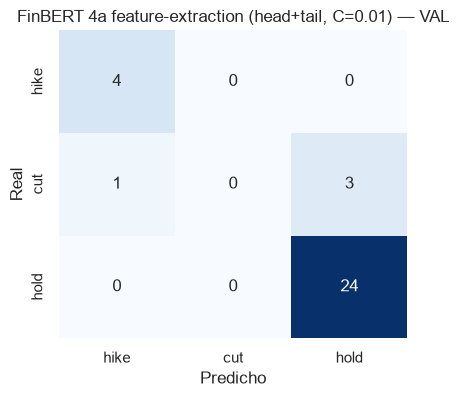

FinBERT 4a feature-extraction (head+tail, C=0.01) — TEST
accuracy : 0.5938
f1_macro : 0.484  (sobre 3 clases: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       1.00      0.36      0.53        11
         cut       0.20      0.17      0.18         6
        hold       0.61      0.93      0.74        15

    accuracy                           0.59        32
   macro avg       0.60      0.49      0.48        32
weighted avg       0.67      0.59      0.56        32



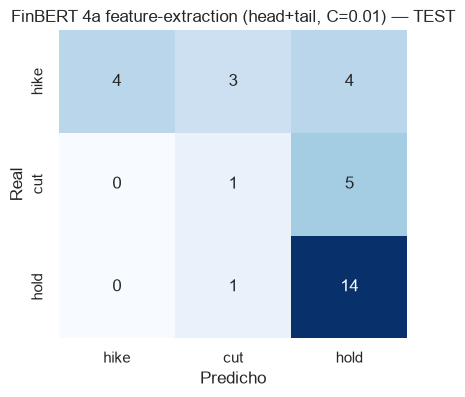

0.4839978734715576

In [8]:
# Evaluar 4a (mejor estrategia) en val y test
_, best_strat, best_C, clf_4a = best
feat = features[best_strat]
evaluar(y_val,  clf_4a.predict(feat['val']),  f'FinBERT 4a feature-extraction ({best_strat}, C={best_C}) — VAL',  '07a_confusion_val.png')
evaluar(y_test, clf_4a.predict(feat['test']), f'FinBERT 4a feature-extraction ({best_strat}, C={best_C}) — TEST', '07a_confusion_test.png')

## 3. Experimento 4b — Fine-tuning

`AutoModelForSequenceClassification` (FinBERT + capa lineal 768→3). Se ajustan **todos** los
pesos. Usamos truncado **head+tail** (estándar para fine-tuning, Sun et al. 2019), `Trainer` de
HuggingFace, **class weights** inversos a la frecuencia, early stopping por F1-macro en val.
Grid: lr ∈ {1e-5, 2e-5, 5e-5} × batch ∈ {4, 8, 16}, máx 5 epochs.

⚠️ Pesado: correr en GPU. En CPU es impracticable el grid completo.

In [9]:
label2id = {l: i for i, l in enumerate(LABEL_ORDER)}
id2label = {i: l for l, i in label2id.items()}

class FinbertDataset(torch.utils.data.Dataset):
    """Tokeniza con head+tail; el collator hace el padding dinámico."""
    def __init__(self, texts, labels):
        self.texts = list(texts); self.labels = [label2id[l] for l in labels]
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        ids = ids_head_tail(self.texts[i])
        return {'input_ids': ids, 'attention_mask': [1]*len(ids), 'labels': self.labels[i]}

ds_train = FinbertDataset(train['raw'], y_train)
ds_val   = FinbertDataset(val['raw'],   y_val)
ds_test  = FinbertDataset(test['raw'],  y_test)
collator = DataCollatorWithPadding(tokenizer)

# Class weights inversos a la frecuencia (sobre train)
counts = train['label'].value_counts()
w = torch.tensor([len(train) / (len(LABEL_ORDER) * counts[l]) for l in LABEL_ORDER],
                 dtype=torch.float)
print('Class weights:', dict(zip(LABEL_ORDER, w.tolist())))

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=w.to(model.device))(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=-1)
    return {'f1_macro': f1_score(p.label_ids, preds, average='macro')}

Class weights: {'hike': 1.9333332777023315, 'cut': 2.685185194015503, 'hold': 0.47385621070861816}


In [10]:
# Grid search lr x batch (early stopping por F1-macro en val)
from transformers import EarlyStoppingCallback

# ⚠️ Fine-tuning PESADO: correr en GPU. En Mac/MPS el grid completo es impracticable.
# Dejar en False para saltar 4b al ejecutar en CPU/MPS; poner True en la PC con GPU.
RUN_FINETUNING = True

def train_one(lr, batch_size, epochs=5):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id).to(device)
    args = TrainingArguments(
        output_dir=str(BASE_DIR / 'tmp_finbert' / f'lr{lr}_bs{batch_size}'),  # dir único por config
        learning_rate=lr, per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=16, num_train_epochs=epochs,
        eval_strategy='epoch', save_strategy='epoch', logging_strategy='epoch',
        load_best_model_at_end=True, metric_for_best_model='f1_macro', greater_is_better=True,
        weight_decay=0.01, seed=33, report_to='none', disable_tqdm=True,
        save_total_limit=1)
    trainer = WeightedTrainer(
        model=model, args=args, train_dataset=ds_train, eval_dataset=ds_val,
        data_collator=collator, compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
    trainer.train()
    f1v = trainer.evaluate(ds_val)['eval_f1_macro']
    return trainer, f1v

best_ft = None  # (f1, lr, batch, trainer)
if RUN_FINETUNING:
    for lr in [1e-5, 2e-5, 5e-5]:
        for bs in [4, 8, 16]:
            print(f'== lr={lr} batch={bs} ==')
            trainer, f1v = train_one(lr, bs)
            print(f'   F1-macro val = {f1v:.4f}')
            if best_ft is None or f1v > best_ft[0]:
                best_ft = (f1v, lr, bs, trainer)
    print(f'\nMejor fine-tuning: lr={best_ft[1]} batch={best_ft[2]} -> F1-macro val {best_ft[0]:.4f}')
else:
    print('4b SKIP: RUN_FINETUNING=False (correr el grid en la PC con GPU). best_ft=None')

== lr=1e-05 batch=4 ==


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 42606.51it/s]

{'loss': '1.466', 'grad_norm': '19.22', 'learning_rate': '8.054e-06', 'epoch': '1'}


{'eval_loss': '0.8297', 'eval_f1_macro': '0.5043', 'eval_runtime': '1.017', 'eval_samples_per_second': '31.47', 'eval_steps_per_second': '1.967', 'epoch': '1'}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.58it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.57it/s]

{'train_runtime': '56.43', 'train_samples_per_second': '12.85', 'train_steps_per_second': '0.886', 'train_loss': '0.6321', 'epoch': '5'}


{'eval_loss': '0.8815', 'eval_f1_macro': '0.7496', 'eval_runtime': '1.199', 'eval_samples_per_second': '26.7', 'eval_steps_per_second': '1.669', 'epoch': '5'}
   F1-macro val = 0.7496

Mejor fine-tuning: lr=1e-05 batch=8 -> F1-macro val 0.8450


FinBERT 4b fine-tuning (lr=1e-05, batch=8) — VAL
accuracy : 0.9375
f1_macro : 0.845  (sobre 3 clases: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       0.80      1.00      0.89         4
         cut       1.00      0.50      0.67         4
        hold       0.96      1.00      0.98        24

    accuracy                           0.94        32
   macro avg       0.92      0.83      0.85        32
weighted avg       0.94      0.94      0.93        32



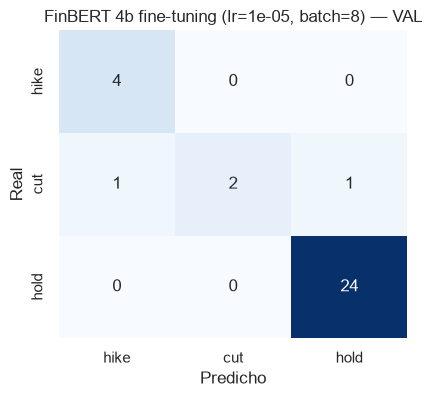

FinBERT 4b fine-tuning (lr=1e-05, batch=8) — TEST
accuracy : 0.75
f1_macro : 0.7413  (sobre 3 clases: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       0.86      0.55      0.67        11
         cut       0.71      0.83      0.77         6
        hold       0.72      0.87      0.79        15

    accuracy                           0.75        32
   macro avg       0.76      0.75      0.74        32
weighted avg       0.77      0.75      0.74        32



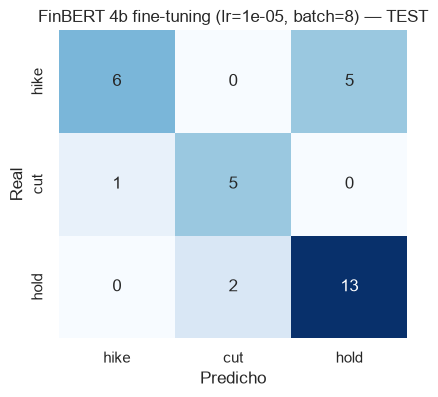

In [11]:
# Evaluar 4b (mejor config) en val y test
if best_ft is not None:
    best_trainer = best_ft[3]

    def predict_labels(trainer, ds):
        logits = trainer.predict(ds).predictions
        return [id2label[i] for i in np.argmax(logits, axis=-1)]

    evaluar(y_val,  predict_labels(best_trainer, ds_val),
            f'FinBERT 4b fine-tuning (lr={best_ft[1]}, batch={best_ft[2]}) — VAL',  '07b_confusion_val.png')
    evaluar(y_test, predict_labels(best_trainer, ds_test),
            f'FinBERT 4b fine-tuning (lr={best_ft[1]}, batch={best_ft[2]}) — TEST', '07b_confusion_test.png')
else:
    print('4b sin resultados (RUN_FINETUNING=False).')
    print('Para regenerar 07b_*.png: poné RUN_FINETUNING=True y corré el grid en la PC con GPU.')

## 4. Interpretación

> **Nota:** todos los números de abajo son sobre el dataset **enmascarado** (anti-leakage): se
> removió la mención explícita de la decisión en las minutas. La comparación contra la versión
> original *con leakage* (4a 0.502 / 4b 0.648) está en `finbert_resultados.md`.

**FinBERT fine-tuneado (4b) es el mejor modelo del trabajo.** Comparativa F1-macro (enmascarado):

| Modelo | val | test |
|--------|-----|------|
| Baseline | 0.286 | 0.213 |
| Exp 1 TF-IDF | 0.519 | 0.213 |
| Exp 2 LM lexicón | 0.524 | 0.154 |
| Exp 3 Word2Vec | 0.691 | 0.396 |
| Exp 4a FinBERT frozen | 0.610 | 0.484 |
| **Exp 4b FinBERT fine-tuning** | **0.845** | **0.741** |

- **El enmascarado NO degrada a FinBERT — al contrario.** Frente a la versión con leakage (4a 0.502,
  4b 0.648), el frozen baja apenas (0.502→0.484) y el fine-tuneado **sube** (0.648→**0.741**). Es
  decir: FinBERT **no estaba leyendo** la decisión explícita en el texto; la **infiere** del tono y
  la discusión. Quitar el *tell* explícito incluso ayuda (menos ruido superficial, más señal real).
- **4b > 4a (fine-tuning > feature extraction):** val 0.845 vs 0.610, test 0.741 vs 0.484. Con 145
  docs, reentrenar los 110M parámetros **no sobreajusta**: generaliza mejor. Clave: lr bajo (1e-5),
  class weights, early stopping. Con lr=5e-5 el entrenamiento se desestabiliza (colapsa a F1≈0.07
  en épocas tempranas); lr=1e-5/batch=8 es la config ganadora.
- **Único modelo balanceado en las 3 clases en test:** cut recall **0.83** (5/6) — los recortes de
  normalización 2024–25 que ningún modelo previo captaba —, hike 0.55, hold 0.87. Word2Vec acertaba
  hike pero ignoraba cut; 4b reparte el acierto y por eso el F1-macro salta.
- **4a (chunking/head+tail) ya era fuerte** (test 0.484) pero la **adaptación a la tarea** (4b) es
  lo que da el salto final.
- **Cierre de la escalera del trabajo:** léxico (TF-IDF) → tono (LM) → semántica (Word2Vec) →
  **contexto + adaptación (FinBERT FT)**. Cada escalón resolvió el límite del anterior.

**Conclusión:** un transformer financiero fine-tuneado alcanza F1-macro de test **0.74** sobre el
dataset enmascarado (casi el doble del mejor modelo clásico) y es el único que reconoce las tres
decisiones fuera de muestra. Que el resultado **se sostenga (y mejore) al enmascarar** confirma que
no es leakage: el modelo entiende la discusión, no solo lee la respuesta.